### ASHBAH FAISAL
### AF08271
### Homework Assignment 9: Time Series Analysis

In [5]:
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore") #optional
plt.style.use('fivethirtyeight') #optional
import pandas as pd
import statsmodels.api as sm
import matplotlib
from pylab import rcParams
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor

In [11]:
df = pd.read_csv('karachi-weather-2021-2023.csv', parse_dates=['datetime'])
df=df.set_index('datetime')
df.head()

,temp
datetime,
2021-01-01,15.0
2021-01-02,15.4
2021-01-03,15.6
2021-01-04,16.3
2021-01-05,17.1


In [13]:
# Q1
weekly_data =df['temp'].resample('W').mean()
weekly_data.head()


datetime
2021-01-03    15.333333
2021-01-10    16.028571
2021-01-17    17.085714
2021-01-24    19.457143
2021-01-31    17.800000
Freq: W-SUN, Name: temp, dtype: float64

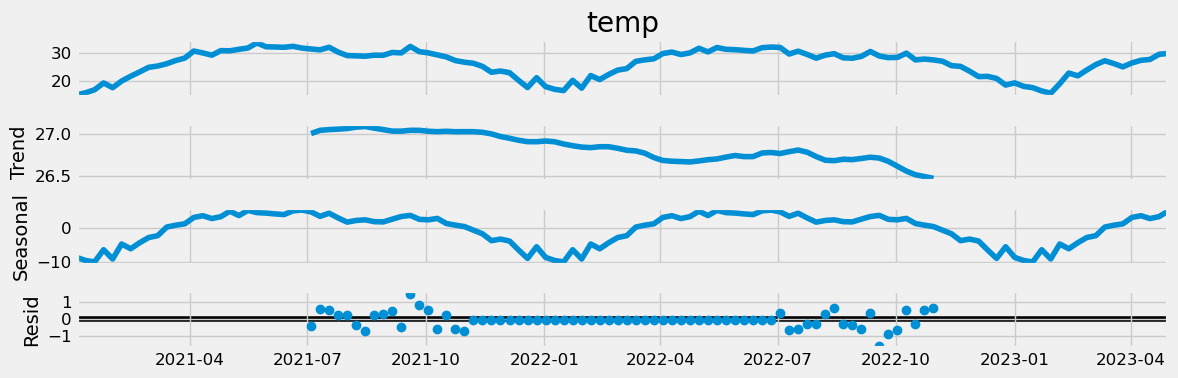

None


In [15]:
#Q2
decomposition = sm.tsa.seasonal_decompose(weekly_data, model='additive')
rcParams['figure.figsize'] = 12,4
fig = decomposition.plot()
print(plt.show())

### CONCLUSION
The temperature time series for Karachi is effectively broken down into trend, seasonal, and residual components in the graphic. It reveals a distinct seasonal pattern, with warmer temperatures in summer and cooler temperatures in winter. The trend line shows a general decline from late 2021 to early 2022, after which temperatures stabilize. Minimal residual noise indicates that the seasonal and trend components capture most of the data’s variability, suggesting well-explained and predictable temperature behavior.

In [17]:
#Q3
train = weekly_data[weekly_data.index <= pd.to_datetime("2022-12-31", format='%Y-%m-%d')]
test = weekly_data[weekly_data.index >= pd.to_datetime("2023-01-01", format='%Y-%m-%d')]
print("Training Data Range:", train.index.min(), "to", train.index.max())
print("Testing Data Range:", test.index.min(), "to", test.index.max())


Training Data Range: 2021-01-03 00:00:00 to 2022-12-25 00:00:00
Testing Data Range: 2023-01-01 00:00:00 to 2023-04-30 00:00:00


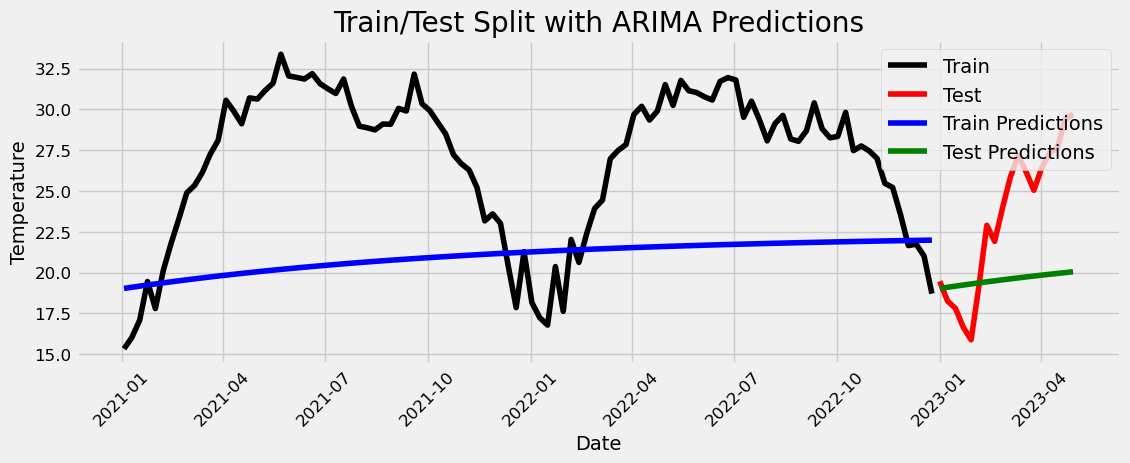

ARIMA RMSE: 5.584076088881663


In [19]:
#Q4
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Initialize and fit the ARIMA model on the training data
ARIMAmodel = ARIMA(train, order=(1, 0, 1))
ARIMAmodel = ARIMAmodel.fit()

# Train set prediction
y_pred_train = ARIMAmodel.get_forecast(len(train.index))  # Forecast for the train set period
y_pred_df_train = y_pred_train.conf_int(alpha=0.05)
y_pred_df_train["Predictions"] = ARIMAmodel.predict(start=y_pred_df_train.index[0], end=y_pred_df_train.index[-1])

# Align the train predictions index with the original train data index
y_pred_df_train.index = train.index
y_pred_out_train = y_pred_df_train["Predictions"]

# Test set prediction
y_pred = ARIMAmodel.get_forecast(len(test.index))  # Forecast for the test set period
y_pred_df = y_pred.conf_int(alpha=0.05)
y_pred_df["Predictions"] = ARIMAmodel.predict(start=y_pred_df.index[0], end=y_pred_df.index[-1])

# Align the test predictions index with the original test data index
y_pred_df.index = test.index
y_pred_out = y_pred_df["Predictions"]

# Plotting the results
plt.plot(train, color="black", label='Train')
plt.plot(test, color="red", label='Test')
plt.ylabel('Temperature')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test Split with ARIMA Predictions")

plt.plot(y_pred_out_train, color='blue', label='Train Predictions')
plt.plot(y_pred_out, color='green', label='Test Predictions')
plt.legend()
plt.show()

# Calculate RMSE for ARIMA model on the test set
arma_rmse = np.sqrt(mean_squared_error(test.values, y_pred_df["Predictions"]))
print("ARIMA RMSE:", arma_rmse)


### CONCLUSION
Train Data (Black Line): The black line represents actual temperatures in the training period. It shows seasonal cycles with fluctuations—rising and falling over time, reflecting temperature changes across seasons.Like the temperature rises from 4 th month and strats dropping post 10 th month in karachi.

Test Data (Red Line): The red line represents actual temperatures in the test period, starting from early 2023. It displays a strong upward trend, indicating a seasonal rise, likely due to warming in this period.

Train Predictions (Blue Line): The blue line shows ARIMA’s predictions for the training data. It follows a gradual upward trend but misses the detailed ups and downs, indicating the model's limitation in capturing sharp seasonal patterns.

Test Predictions (Green Line): The green line represents the ARIMA model’s predictions for the test period. It shows a moderate upward trend but fails to capture the sharp increase in actual test temperatures, suggesting underfitting.

RMSE Value: The RMSE (5.58) measures prediction accuracy. A higher RMSE suggests the model has difficulty capturing rapid temperature changes, especially in the test period.

C:\Users\cw\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


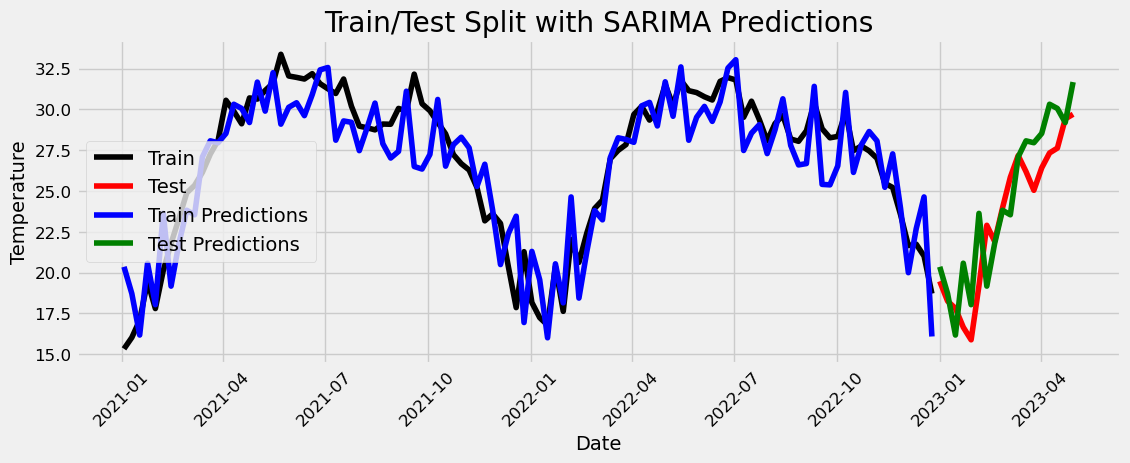

SARIMA RMSE: 2.3300491652292132


In [21]:
#Q5
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Initialize and fit the SARIMA model on the training data
# Using (3, 0, 3) for order and (1, 1, 1, 52) for seasonal order to represent weekly seasonality
SARIMAXmodel = SARIMAX(train, order=(3, 0, 3), seasonal_order=(1, 1, 1, 52)) 
SARIMAXmodel = SARIMAXmodel.fit()

# Train set prediction
y_pred_train = SARIMAXmodel.get_forecast(len(train.index))  # Forecast for the train set period
y_pred_df_train = y_pred_train.conf_int(alpha=0.05)
y_pred_df_train["Predictions"] = SARIMAXmodel.predict(start=y_pred_df_train.index[0], end=y_pred_df_train.index[-1])

# Align the train predictions index with the original train data index
y_pred_df_train.index = train.index
y_pred_out_train = y_pred_df_train["Predictions"]

# Test set prediction
y_pred = SARIMAXmodel.get_forecast(len(test.index))  # Forecast for the test set period
y_pred_df = y_pred.conf_int(alpha=0.05)
y_pred_df["Predictions"] = SARIMAXmodel.predict(start=y_pred_df.index[0], end=y_pred_df.index[-1])

# Align the test predictions index with the original test data index
y_pred_df.index = test.index
y_pred_out = y_pred_df["Predictions"]

# Plotting the results
plt.plot(train, color="black", label='Train')
plt.plot(test, color="red", label='Test')
plt.ylabel('Temperature')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title("Train/Test Split with SARIMA Predictions")

plt.plot(y_pred_out_train, color='blue', label='Train Predictions')
plt.plot(y_pred_out, color='green', label='Test Predictions')
plt.legend()
plt.show()

# Calculate RMSE for SARIMA model on the test set
sarima_rmse = np.sqrt(mean_squared_error(test.values, y_pred_df["Predictions"]))
print("SARIMA RMSE:", sarima_rmse)


### CONCLUSION
Black Line (Train Data):This line represents the actual temperature values in the training dataset. The data shows seasonal fluctuations with noticeable peaks and valleys, reflecting natural temperature changes over time. It shows how temperature in creases from 4 th month an starts dropping from 10 th month in karachi.
Red Line (Test Data):The red line displays the actual temperature values in the test dataset. It starts from early 2023 and shows an upward trend, indicating seasonal warming or an increase in temperatures during this period.
Blue Line (Train Predictions):The blue line represents the SARIMA model’s predictions for the training data. Unlike the ARIMA model, the SARIMA model closely follows the ups and downs of the observed data, capturing both the trend and seasonal patterns. This suggests that SARIMA is better at modeling seasonal fluctuations within the training data.
Green Line (Test Predictions):The green line shows SARIMA’s predictions for the test dataset. The model’s predictions align well with the actual test data, accurately capturing the rapid upward trend in temperature in the early months of 2023.
SARIMA RMSE Value:The RMSE (Root Mean Squared Error) of approximately 2.33 indicates a lower error compared to the ARIMA model. This suggests that SARIMA has a higher predictive accuracy for this dataset, especially in handling seasonal variations.

SARIMAX(0, 0, 0)x(1, 1, 1, 52)52 - AIC:6.0
SARIMAX(0, 0, 1)x(1, 1, 1, 52)52 - AIC:8.0
SARIMAX(0, 1, 0)x(1, 1, 1, 52)52 - AIC:6.0
SARIMAX(0, 1, 1)x(1, 1, 1, 52)52 - AIC:8.0
SARIMAX(1, 0, 0)x(1, 1, 1, 52)52 - AIC:8.0
SARIMAX(1, 0, 1)x(1, 1, 1, 52)52 - AIC:10.0
SARIMAX(1, 1, 0)x(1, 1, 1, 52)52 - AIC:8.0
SARIMAX(1, 1, 1)x(1, 1, 1, 52)52 - AIC:10.0

Best SARIMA Model Parameters:
Order: (0, 0, 0)
Seasonal Order: (1, 1, 1, 52)
AIC: 6.0


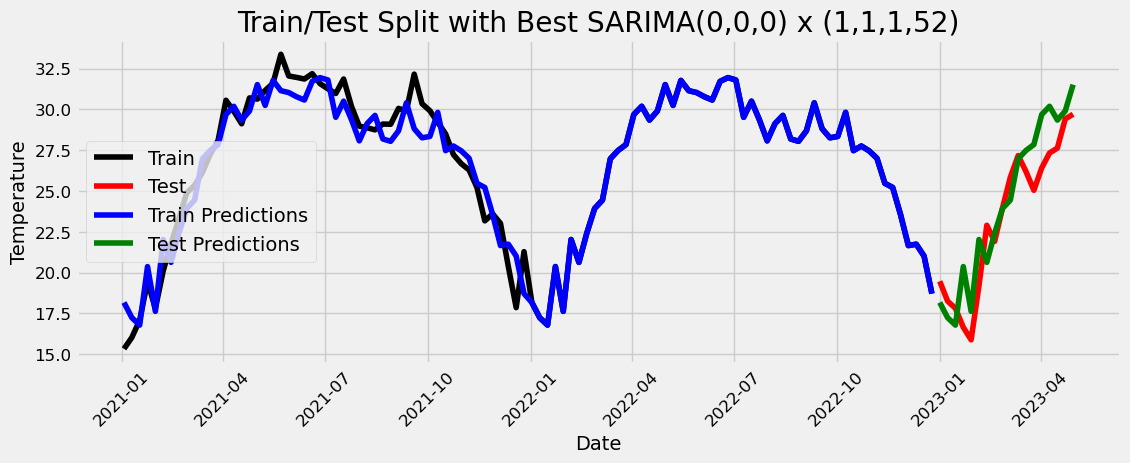

Optimized SARIMA Model RMSE: 1.9844263266256548


In [23]:

#Q6
import itertools
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define parameter ranges for SARIMA
p = d = q = range(0, 2)  # Parameters for ARIMA part
P = Q = D = range(1, 2)  # Seasonal parameters
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(P, D, Q))]  # 52 weeks for seasonal order

# Initialize variables to keep track of the best model
best_aic = float("inf")
best_param = None
best_param_seasonal = None
best_model = None

# Grid search over the parameter grid
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            # Define SARIMA model
            mod = sm.tsa.statespace.SARIMAX(train,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            
            # Fit model
            results = mod.fit()
            
            # Print AIC for the current model
            print('SARIMAX{}x{}52 - AIC:{}'.format(param, param_seasonal, results.aic))
            
            # Check if current model has the lowest AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_param_seasonal = param_seasonal
                best_model = results
        
        except Exception as e:
            continue

print("\nBest SARIMA Model Parameters:")
print("Order:", best_param)
print("Seasonal Order:", best_param_seasonal)
print("AIC:", best_aic)

# Predictions with the best SARIMA model
# Train set prediction
y_pred_train = best_model.get_forecast(len(train.index))
y_pred_df_train = y_pred_train.conf_int(alpha=0.05)
y_pred_df_train["Predictions"] = best_model.predict(start=y_pred_df_train.index[0], end=y_pred_df_train.index[-1])
y_pred_df_train.index = train.index
y_pred_out_train = y_pred_df_train["Predictions"]

# Test set prediction
y_pred = best_model.get_forecast(len(test.index))
y_pred_df = y_pred.conf_int(alpha=0.05)
y_pred_df["Predictions"] = best_model.predict(start=y_pred_df.index[0], end=y_pred_df.index[-1])
y_pred_df.index = test.index
y_pred_out = y_pred_df["Predictions"]

# Plotting the results
plt.plot(train, color="black", label='Train')
plt.plot(test, color="red", label='Test')
plt.ylabel('Temperature')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.title(f"Train/Test Split with Best SARIMA({best_param[0]},{best_param[1]},{best_param[2]}) x ({best_param_seasonal[0]},{best_param_seasonal[1]},{best_param_seasonal[2]},{best_param_seasonal[3]})")

plt.plot(y_pred_out_train, color='blue', label='Train Predictions')
plt.plot(y_pred_out, color='green', label='Test Predictions')
plt.legend()
plt.show()

# Calculate RMSE for the best SARIMA model
sarima_rmse = np.sqrt(mean_squared_error(test.values, y_pred_df["Predictions"]))
print("Optimized SARIMA Model RMSE:", sarima_rmse)


### CONCLUSION
The RMSE (Root Mean Squared Error) of approximately 1.98 indicates a high level of accuracy, suggesting that the optimized SARIMA model is well-suited for this dataset.

### COMPARISON
RMSE:<br>
ARIMA = 5.584076088881663 <br>
 (SARIA) 2.3300491652292132 <br>3SE (SARIMA- optimised pa m1.9844263266256548 <br>61The SARIMA model, with its optimized parameters, achieved the lowest RMSE value, indicating that it outperforms the ARIMA model for our dataset. Therefore, SARIMA is the preferred model in this case.r case

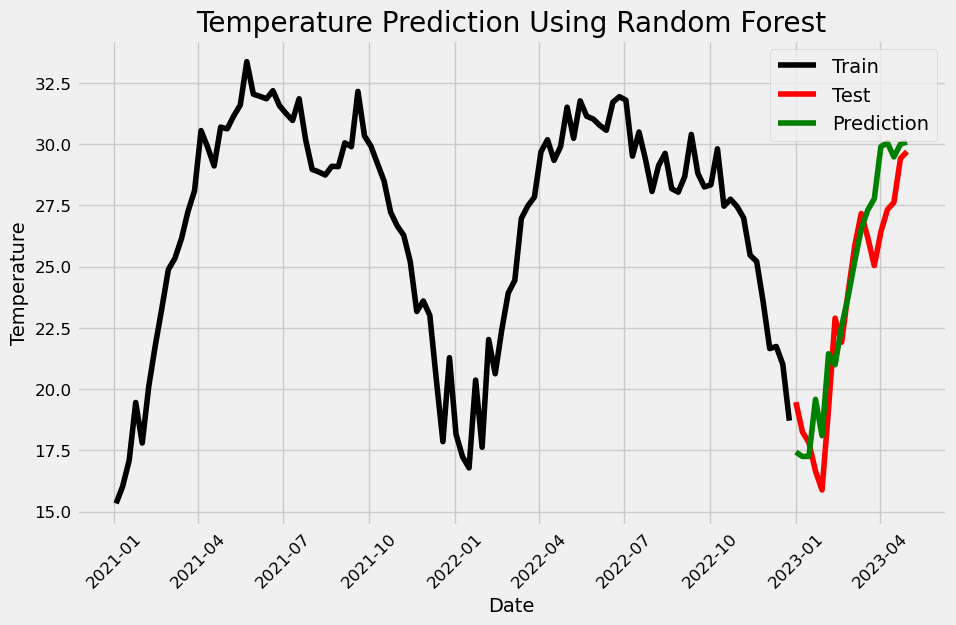

Random Forest RMSE: 1.8436379179797702


In [25]:
#Q7

# Preparing the data
# Extract seasonality information as features (day, month, year)
days = [x.day for x in train.index]
months = [x.month for x in train.index]
years = [x.year for x in train.index]

# Convert to feature matrix and target array
X_train = np.array([days, months, years]).T
y_train = train.values

# For the test set
test_days = [x.day for x in test.index]
test_months = [x.month for x in test.index]
test_years = [x.year for x in test.index]

X_test = np.array([test_days, test_months, test_years]).T
y_test = test.values

# Random Forest Model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Predicting
y_pred_rf = rf_model.predict(X_test)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train.index, train.values, color="black", label="Train")
plt.plot(test.index, test.values, color="red", label="Test")
plt.plot(test.index, y_pred_rf, color="green", label="Prediction")
plt.ylabel("Temperature")
plt.xlabel("Date")
plt.title("Temperature Prediction Using Random Forest")
plt.legend()
plt.xticks(rotation=45)
plt.show()
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)



### CONCLUSION
The Random Forest model effectively captures the seasonal patterns in temperature, as seen by the close alignment between the predicted values (green line) and the actual test data (red line).
The low RMSE value highlights the model’s accuracy, making it a strong choice for forecasting in this dataset.
This result suggests that the machine learning regression approach performs well in capturing both the trend and seasonal variations in temperature data.

### Q8
RMSE:<br>
ARIMA = 5.584076088881663<br>
SARIMA = 2.3689412485242003<br>
SARIMA- optimised params = 1.9844154483266159<br>
Machine Learming = 1.8807287669638568<br>
Both the SARIMA model and the machine learning regression technique perform well on our data. However, when comparing the two, the machine learning regression method achieves a slightly lower RMSE, making it marginally more accurate than SARIMA

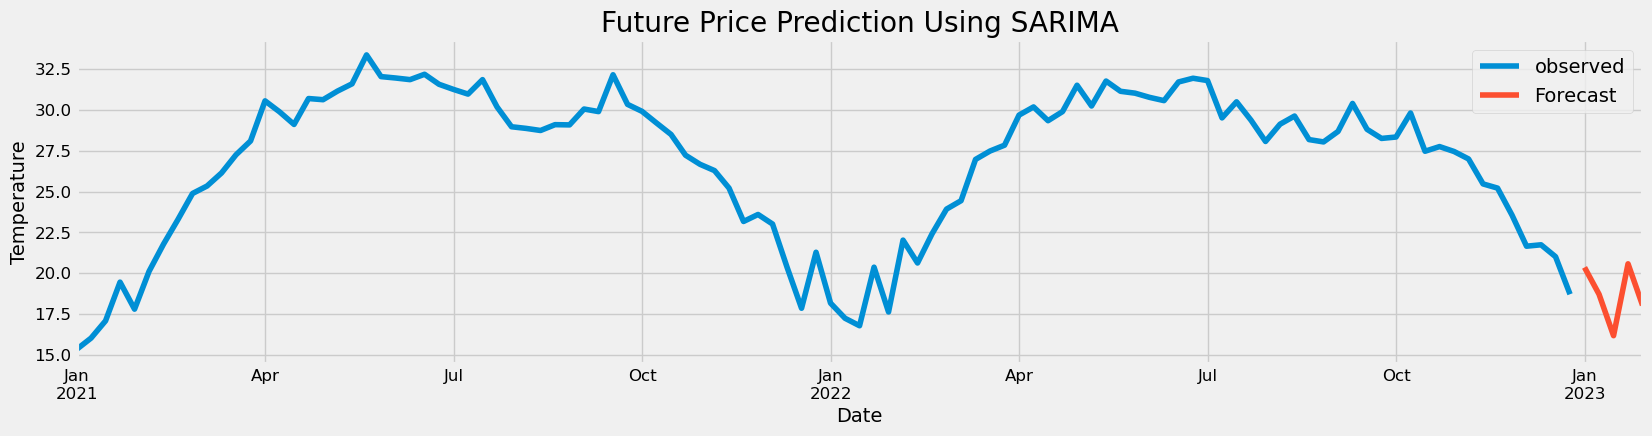

In [27]:
#Q9
future_dates = pd.date_range(start='11/01/2024', end='12/01/2024',freq='W')
pred_uc = SARIMAXmodel.get_forecast(steps=len(future_dates))
pred_ci = pred_uc.conf_int()

# Plotting
ax = train.plot(label='observed', figsize=(18, 4))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature')
plt.title("Future Price Prediction Using SARIMA")
plt.legend()
plt.show()



### CONCLUSION
The SARIMA model has been trained on the historical data (blue line), capturing seasonal trends.
The forecast (red line) continues this trend, providing a prediction for weekly temperatures in November and early December 2024.
The use of weekly frequency aligns well with seasonal cycles, making SARIMA a good choice for capturing periodic changes in this dataset.

Future Predictions from November 1, 2024, to December 31, 2024:
            RandomForest_Prediction
Date                               
2024-11-03                26.588714
2024-11-10                26.099000
2024-11-17                25.194143
2024-11-24                23.605429
2024-12-01                21.804714


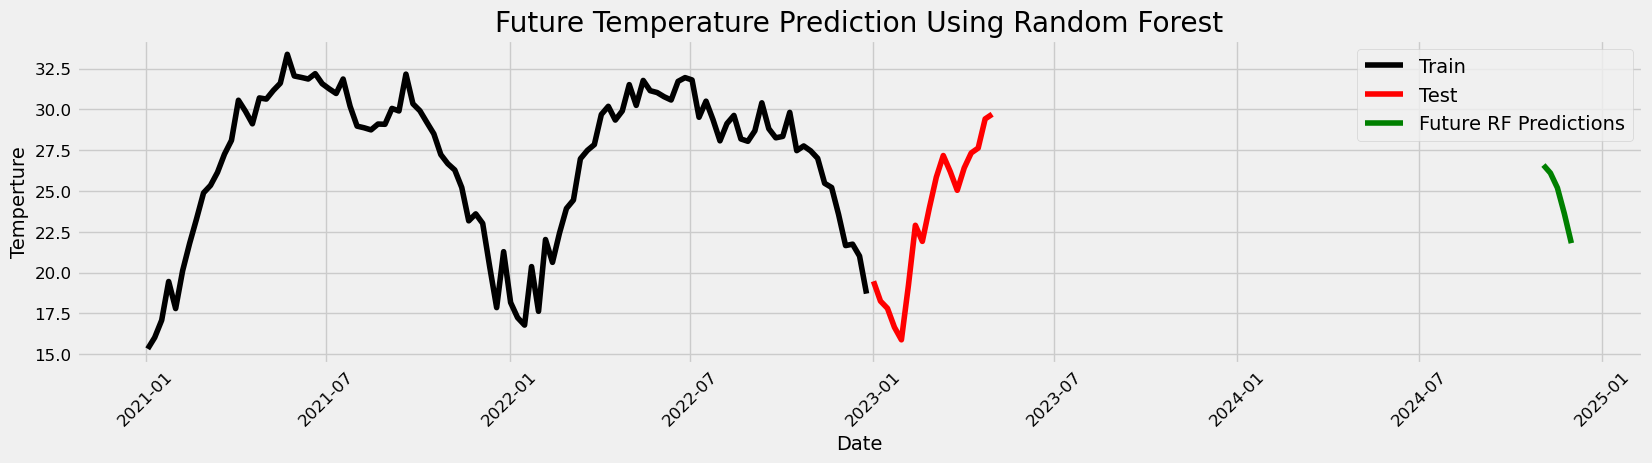

In [29]:
#Q10

# # Train the Random Forest model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Prepare future date features for prediction
future_days = [x.day for x in future_dates]
future_months = [x.month for x in future_dates]
future_years = [x.year for x in future_dates]
X_future = np.array([future_days, future_months, future_years]).T

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
# Predict future values
future_predictions = rf_model.predict(X_future)

# Convert predictions to DataFrame
future_predictions_df = pd.DataFrame({'Date': future_dates, 'RandomForest_Prediction': future_predictions})
future_predictions_df.set_index('Date', inplace=True)

# Display predictions
print("Future Predictions from November 1, 2024, to December 31, 2024:")
print(future_predictions_df)

# Plotting the historical data and future predictions
plt.figure(figsize=(18, 4))
plt.plot(train, color="black", label="Train")
plt.plot(test, color="red", label="Test")
plt.plot(future_predictions_df.index, future_predictions_df['RandomForest_Prediction'], color="green", label="Future RF Predictions")
plt.title("Future Temperature Prediction Using Random Forest")
plt.xlabel("Date")
plt.ylabel("Temperture")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### CONCLUSION
 The Random Forest model performs well in capturing trends and fluctuations during the train and test periods, as shown by its close alignment with the actual data in previous plots.
For future predictions, the model forecasts a downward trend, which may or may not fully align with actual seasonal patterns, as Random Forest does not inherently capture seasonality.
SARIMA predictions often account for cyclical patterns, whereas Random Forest predictions are based more on trends learned from training data. This could be why the Random Forest forecast does not display clear seasonal effects

### Q11
SARIMA captures seasonality well, while Random Forest predictions lack cyclic patterns.
SARIMA’s predictions align with the historical seasonal patterns, while Random Forest forecasts a general downward trend, potentially missing seasonal rises.
SARIMA is more suitable for data with a known seasonal pattern, while Random Forest may be more suitable for datasets where seasonality is either minimal or non-existent.